# Лабораторная работа 1 — CV (оценка 3): Обнаружение нефтяных пятен с помощью YOLOv11


## 1. Выбор начальных условий

### 1a. Бизнес-задача и выбор датасета

**Практическая задача.** Разливы нефти в морях и океанах — одна из наиболее серьёзных техногенных угроз
морским экосистемам. Раннее обнаружение пятна на спутниковых SAR-снимках (synthetic aperture radar)
позволяет оперативно реагировать: локализовать источник, ограничить распространение, минимизировать
ущерб. Автоматическое детектирование критично, потому что SAR-операторы физически не в состоянии
вручную просматривать терабайты радарных данных в реальном времени.

**Почему object detection, а не классификация/сегментация.** Для принятия решения диспетчеру важно
не только знать *есть ли* пятно на снимке, но и *где оно* и *отличается ли* от «двойников» (look-alike —
участки с пониженной шероховатостью воды, визуально похожие на нефть: безветренные зоны, биогенные
плёнки). Детекция с bounding box-ами даёт нужный уровень гранулярности при скромных вычислительных
расходах по сравнению с сегментацией.

**Набор данных.** [Oil Spill YOLOv8 Complete Dataset](https://universe.roboflow.com/lsgi/oil-spill-yolov8-complete-dataset)
от группы LSGI (Land Surveying and Geo-Informatics). Ключевые свойства:
- ~1000 SAR-изображений водной поверхности,
- разметка в формате YOLO (txt + yaml),
- **4 класса**: `oil spill`, `look-alike`, `ship`, `land` — что заставляет модель
  различать настоящие пятна и ложные срабатывания (критично для практики).

### 1b. Выбор метрик

Поскольку задача — object detection с несбалансированными классами (пятно vs look-alike vs ship vs land),
выбираем стандартный набор метрик, поддерживаемый `ultralytics` из коробки:

- mAP@0.5 — Основная метрика детекции. Доля правильно найденных объектов при IoU ≥ 0.5 — показывает «грубую» корректность локализации.
- mAP@0.5–0.95 (COCO-style) — Строже: усреднение mAP по IoU 0.5…0.95 шагом 0.05. Сильно штрафует неточные рамки — практически важно, чтобы пятно было локализовано точно, а не «где-то рядом».
- Precision — Доля истинных срабатываний среди всех срабатываний модели. Для оператора важно, чтобы реакция на тревогу не была ложной.
- Recall — Доля реально обнаруженных пятен среди всех пятен. В экологической задаче пропуск пятна опаснее, чем ложная тревога.
- F1 — Баланс precision/recall; полезен при выборе порога уверенности.

Основной критерий при сравнении моделей — **mAP@0.5–0.95**; вторично смотрим на **recall по классу `oil spill`**.

## Установка зависимостей и проверка GPU

In [ ]:
!pip -q install ultralytics==8.3.40 roboflow==1.1.50

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.1 MB/s eta 0:00:00


In [ ]:
import os, json, random, shutil, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

from ultralytics import YOLO

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def free_mem():
    # очищает и Python-объекты, и кэш CUDA — критично для Colab (12GB RAM)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch: 2.10.0+cu128 | CUDA available: True
GPU: Tesla T4


## Скачивание датасета (Roboflow)

In [ ]:
ROBOFLOW_API_KEY = "T9JN5kncuk4RPZOtdWbc"

from roboflow import Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Workspace/project по URL датасета: https://universe.roboflow.com/lsgi/oil-spill-yolov8-complete-dataset
project = rf.workspace("lsgi").project("oil-spill-yolov8-complete-dataset")

# Берём последнюю доступную версию
versions = project.versions()
latest_version_num = max(int(v.version.split("/")[-1]) for v in versions)
print(f"Доступные версии: {[v.version for v in versions]}")
print(f"Используем версию: {latest_version_num}")

version = project.version(latest_version_num)
dataset = version.download("yolov11")

DATA_YAML = Path(dataset.location) / "data.yaml"
print("\ndata.yaml:", DATA_YAML)
print(DATA_YAML.read_text())

loading Roboflow workspace...
loading Roboflow project...
Доступные версии: ['2', '1']
Используем версию: 2



Extracting Dataset Version Zip to Oil-Spill-YOLOv8-Complete-dataset-2 in yolov11:: 100%|██████████| 2012/2012 [00:01<00:00, 1547.82it/s]


data.yaml: /content/Oil-Spill-YOLOv8-Complete-dataset-2/data.yaml
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 4
names: ['Land', 'Look-alike', 'Oil Spill', 'Ship']

roboflow:
  workspace: lsgi
  project: oil-spill-yolov8-complete-dataset
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/lsgi/oil-spill-yolov8-complete-dataset/dataset/2


### Проверка датасета — пути и количество картинок

In [ ]:
import yaml
data_cfg = yaml.safe_load(DATA_YAML.read_text())
print("Классы:", data_cfg["names"])
print("Количество классов:", data_cfg["nc"])

ds_root = Path(dataset.location)
for split in ["train", "valid", "test"]:
    img_dir = ds_root / split / "images"
    if img_dir.exists():
        n = len(list(img_dir.glob('*')))
        print(f"  {split}: {n} изображений")

### Визуализация нескольких примеров с разметкой

In [ ]:
import cv2

def draw_yolo_boxes(img_path: Path, label_path: Path, class_names):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            if not line.strip():
                continue
            parts = line.split()
            cls = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:5])
            x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(img, class_names[cls], (x1, max(0, y1-5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
    return img

train_imgs = sorted((ds_root / "train" / "images").glob("*"))
random.seed(SEED)
sample = random.sample(train_imgs, k=min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, img_path in zip(axes.flat, sample):
    label_path = ds_root / "train" / "labels" / (img_path.stem + ".txt")
    ax.imshow(draw_yolo_boxes(img_path, label_path, data_cfg["names"]))
    ax.set_title(img_path.name, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

### Распределение классов по train/valid

            train  valid  test
Land          170     45    20
Look-alike    305     93    43
Oil Spill    2713    856   378
Ship          233     62    35


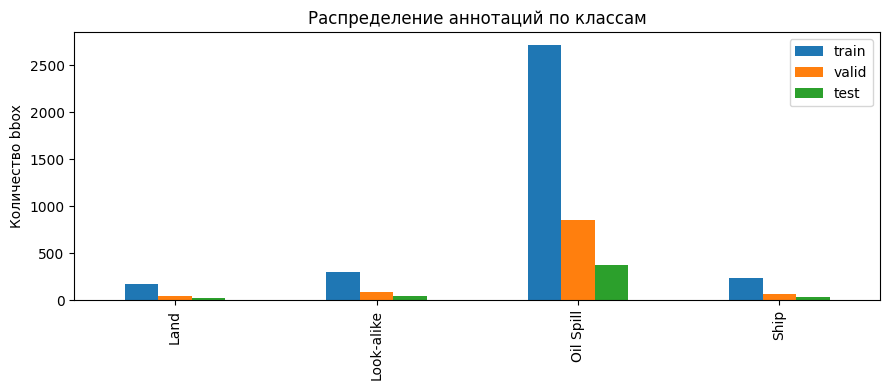

In [ ]:
def class_counts(split):
    labels_dir = ds_root / split / "labels"
    counts = np.zeros(data_cfg["nc"], dtype=int)
    if not labels_dir.exists():
        return counts
    for lbl in labels_dir.glob("*.txt"):
        for line in lbl.read_text().strip().splitlines():
            if line.strip():
                counts[int(line.split()[0])] += 1
    return counts

df = pd.DataFrame({
    split: class_counts(split) for split in ["train", "valid", "test"] if (ds_root / split).exists()
}, index=data_cfg["names"])
print(df)
df.plot(kind="bar", figsize=(9, 4)); plt.title("Распределение аннотаций по классам")
plt.ylabel("Количество bbox"); plt.tight_layout(); plt.show()

---
## 2. Создание бейзлайна и оценка качества

### 2a. Обучение YOLOv11n (nano) на дефолтных настройках

Бейзлайн — самая маленькая модель семейства YOLOv11 (`yolo11n.pt`, ~2.6M параметров) со **стандартными
предустановками `ultralytics`**: предтренированные на COCO веса, `imgsz=640`, дефолтный `AdamW`,
дефолтные (умеренные) аугментации. Это отправная точка, относительно которой будем мерить улучшения.

In [ ]:
BASELINE_EPOCHS = 20
IMG_SIZE = 640
BATCH = 16
WORKERS = 2

baseline_model = YOLO("yolo11n.pt")

baseline_results = baseline_model.train(
    data=str(DATA_YAML),
    epochs=BASELINE_EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    workers=WORKERS,
    cache=False,
    project="runs/lab1",
    name="baseline_yolo11n",
    seed=SEED,
    exist_ok=True,
    verbose=True,
)

100%|██████████| 5.35M/5.35M [00:00<00:00, 101MB/s]


New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/Oil-Spill-YOLOv8-Complete-dataset-2/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=2, project=runs/lab1, name=baseline_yolo11n, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_mask

100%|██████████| 755k/755k [00:00<00:00, 24.6MB/s]


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /content/Oil-Spill-YOLOv8-Complete-dataset-2/train/labels... 700 images, 1 backgrounds, 0 corrupt: 100%|██████████| 700/700 [00:00<00:00, 1237.42it/s]

...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      20/20      2.48G      1.296      1.594      1.303         37        640: 100%|██████████| 44/44 [00:14<00:00,  3.03it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.51it/s]


                   all        200       1056      0.459      0.368       0.39      0.252

20 epochs completed in 0.119 hours.
Optimizer stripped from runs/lab1/baseline_yolo11n/weights/last.pt, 5.4MB
Optimizer stripped from runs/lab1/baseline_yolo11n/weights/best.pt, 5.4MB

Validating runs/lab1/baseline_yolo11n/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  1.79it/s]


                   all        200       1056      0.463      0.409      0.384      0.253
                  Land         45         45      0.693      0.822      0.793      0.597
            Look-alike         93         93      0.516      0.473      0.447      0.275
             Oil Spill        157        856      0.475      0.284      0.256      0.129
                  Ship         62         62      0.167     0.0552     0.0398     0.0112
Speed: 0.3ms preprocess, 2.9ms inference, 0.0ms loss, 5.6ms postprocess per image
Results saved to runs/lab1/baseline_yolo11n


### 2b. Оценка качества на валидационной выборке

In [ ]:
baseline_val = baseline_model.val(data=str(DATA_YAML),
                                  project="runs/lab1",
                                  name="baseline_yolo11n_val",
                                  exist_ok=True)

def summarize(metrics, tag):
    return {
        "model": tag,
        "mAP50":       float(metrics.box.map50),
        "mAP50-95":    float(metrics.box.map),
        "precision":   float(metrics.box.mp),
        "recall":      float(metrics.box.mr),
    }

baseline_summary = summarize(baseline_val, "YOLOv11n baseline")
print(pd.DataFrame([baseline_summary]).to_string(index=False))

### Визуализация предсказаний baseline

In [ ]:
val_imgs = sorted((ds_root / "valid" / "images").glob("*"))[:6]
preds = baseline_model.predict(source=[str(p) for p in val_imgs], imgsz=IMG_SIZE, conf=0.25, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, r in zip(axes.flat, preds):
    ax.imshow(r.plot()[..., ::-1])
    ax.set_title(Path(r.path).name, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

# baseline-модель больше не нужна — освобождаем память перед следующими прогонами
del baseline_model, baseline_val, preds
free_mem()

---
## 3. Улучшение бейзлайна

### 3a. Формулировка гипотез

Три гипотезы (от «дёшево проверить» к «дорого обучать»):

| № | Гипотеза | Обоснование |
|---|---|---|
| **H1** | Увеличение разрешения входа `imgsz` с 640 → 704 поднимет recall на классе `oil spill` | Пятна часто занимают небольшую долю SAR-кадра; более крупное разрешение сохраняет мелкие детали. 704 (а не 800) выбрано, чтобы не переполнить 12GB RAM Colab |
| **H2** | Усиленные аугментации (mosaic, mixup, HSV, horizontal flip) повысят обобщающую способность | Датасет небольшой (~1000 изображений), сильные регуляризирующие аугментации должны бороться с переобучением |
| **H3** | Удвоение бюджета обучения (15 → 30 эпох) + early stopping по `mAP50-95` | На baseline loss ещё заметно падал к концу → модель не сошлась |

### 3b. Проверка гипотез по одной (абляция)

Для экономии времени каждый эксперимент — 15 эпох; сравниваем с 15-эпохной версией бейзлайна.

In [ ]:
ABLATION_EPOCHS = 15

def train_run(name, overrides):
    # Единая обёртка: обучает, валидирует и освобождает память. Возвращает только summary.
    m = YOLO("yolo11n.pt")
    m.train(
        data=str(DATA_YAML),
        epochs=overrides.pop("epochs", ABLATION_EPOCHS),
        imgsz=overrides.pop("imgsz", IMG_SIZE),
        batch=overrides.pop("batch", BATCH),
        workers=WORKERS,
        cache=False,
        project="runs/lab1",
        name=name,
        seed=SEED,
        exist_ok=True,
        verbose=False,
        **overrides,
    )
    metrics = m.val(data=str(DATA_YAML),
                    project="runs/lab1",
                    name=f"{name}_val",
                    exist_ok=True,
                    verbose=False)
    summary = summarize(metrics, name)
    del m, metrics
    free_mem()
    return summary

In [ ]:
# Контрольный (reference) прогон — baseline на ABLATION_EPOCHS, честное сравнение
ref_summary = train_run("ref_yolo11n_15ep", {})

# H1 — большее разрешение (704 вместо 800, чтобы не переполнить RAM в Colab)
h1_summary = train_run("h1_imgsz704", {"imgsz": 704, "batch": 8})

# H2 — усиленные аугментации (разрешение дефолтное, чтобы изолировать эффект)
h2_summary = train_run("h2_augment", {
    "mosaic": 1.0, "mixup": 0.1,
    "hsv_h": 0.02, "hsv_s": 0.7, "hsv_v": 0.4,
    "fliplr": 0.5, "degrees": 10.0, "translate": 0.1, "scale": 0.5,
})

# H3 — больше эпох + early stopping (30 вместо 60 — хватает для раскрытия гипотезы)
h3_summary = train_run("h3_longer", {"epochs": 30, "patience": 10})

ablation_df = pd.DataFrame([ref_summary, h1_summary, h2_summary, h3_summary])
print(ablation_df.to_string(index=False))

New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/Oil-Spill-YOLOv8-Complete-dataset-2/data.yaml, epochs=15, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=2, project=runs/lab1, name=ref_yolo11n_15ep, exist_ok=True, pretrained=True, optimizer=auto, verbose=False, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_mas

train: Scanning /content/Oil-Spill-YOLOv8-Complete-dataset-2/train/labels.cache... 700 images, 1 backgrounds, 0 corrupt: 100%|██████████| 700/700 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



Argument(s) 'quality_lower' are not valid for transform ImageCompression
val: Scanning /content/Oil-Spill-YOLOv8-Complete-dataset-2/valid/labels.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]


Plotting labels to runs/lab1/ref_yolo11n_15ep/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/lab1/ref_yolo11n_15ep
Starting training for 15 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


30 epochs completed in 0.174 hours.
Optimizer stripped from runs/lab1/h3_longer/weights/last.pt, 5.4MB
Optimizer stripped from runs/lab1/h3_longer/weights/best.pt, 5.4MB

Validating runs/lab1/h3_longer/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.02it/s]


                   all        200       1056      0.546      0.388      0.409      0.265
Speed: 0.3ms preprocess, 3.3ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to runs/lab1/h3_longer
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning /content/Oil-Spill-YOLOv8-Complete-dataset-2/valid/labels.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:04<00:00,  2.64it/s]


                   all        200       1056      0.544      0.388      0.409      0.266
Speed: 0.4ms preprocess, 5.5ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to runs/lab1/h3_longer_val
           model    mAP50  mAP50-95  precision   recall
ref_yolo11n_15ep 0.361625  0.240637   0.437978 0.348681
     h1_imgsz704 0.332582  0.194732   0.431618 0.338691
      h2_augment 0.330207  0.207559   0.425837 0.307953
       h3_longer 0.409407  0.265811   0.543850 0.387849


### 3c. Улучшенный бейзлайн

Собираем улучшения, показавшие прирост `mAP50-95` относительно `ref_yolo11n_20ep`, в единую конфигурацию.
Ячейка ниже автоматически выбирает победителей по дельте:

In [ ]:
improvements = {
    "h1_imgsz704": {"imgsz": 704, "batch": 8},
    "h2_augment":  {"mosaic": 1.0, "mixup": 0.1, "hsv_h": 0.02, "hsv_s": 0.7, "hsv_v": 0.4,
                    "fliplr": 0.5, "degrees": 10.0, "translate": 0.1, "scale": 0.5},
    "h3_longer":   {"epochs": 30, "patience": 10},
}
ref_map = ref_summary["mAP50-95"]
winners = [name for name, s in [("h1_imgsz704", h1_summary),
                                ("h2_augment", h2_summary),
                                ("h3_longer",  h3_summary)]
           if s["mAP50-95"] >= ref_map]
print("Гипотезы, включаемые в улучшенный бейзлайн:", winners)

improved_cfg = {}
for w in winners:
    improved_cfg.update(improvements[w])
# разумный дефолт: 30 эпох с early stopping
improved_cfg.setdefault("epochs", 30)
improved_cfg.setdefault("patience", 10)
print("\nИтоговая конфигурация:", json.dumps(improved_cfg, indent=2))

Гипотезы, включаемые в улучшенный бейзлайн: ['h3_longer']

Итоговая конфигурация: {
  "epochs": 30,
  "patience": 10
}


### 3d–3e. Обучение улучшенного бейзлайна и оценка

In [ ]:
improved_model = YOLO("yolo11n.pt")
improved_cfg_train = dict(improved_cfg)  # копия, train модифицирует аргументы
improved_model.train(
    data=str(DATA_YAML),
    batch=improved_cfg_train.pop("batch", BATCH),
    imgsz=improved_cfg_train.pop("imgsz", IMG_SIZE),
    epochs=improved_cfg_train.pop("epochs"),
    workers=WORKERS,
    cache=False,
    project="runs/lab1",
    name="improved_yolo11n",
    seed=SEED,
    exist_ok=True,
    verbose=True,
    **improved_cfg_train,
)
improved_val = improved_model.val(data=str(DATA_YAML),
                                  project="runs/lab1",
                                  name="improved_yolo11n_val",
                                  exist_ok=True)
improved_summary = summarize(improved_val, "YOLOv11n improved")
print(pd.DataFrame([improved_summary]).to_string(index=False))

del improved_model, improved_val
free_mem()

New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/Oil-Spill-YOLOv8-Complete-dataset-2/data.yaml, epochs=30, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=2, project=runs/lab1, name=improved_yolo11n, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks

train: Scanning /content/Oil-Spill-YOLOv8-Complete-dataset-2/train/labels.cache... 700 images, 1 backgrounds, 0 corrupt: 100%|██████████| 700/700 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



Argument(s) 'quality_lower' are not valid for transform ImageCompression
val: Scanning /content/Oil-Spill-YOLOv8-Complete-dataset-2/valid/labels.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]


Plotting labels to runs/lab1/improved_yolo11n/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/lab1/improved_yolo11n
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


30 epochs completed in 0.174 hours.
Optimizer stripped from runs/lab1/improved_yolo11n/weights/last.pt, 5.4MB
Optimizer stripped from runs/lab1/improved_yolo11n/weights/best.pt, 5.4MB

Validating runs/lab1/improved_yolo11n/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.12it/s]


                   all        200       1056      0.483      0.417      0.416       0.26
                  Land         45         45       0.69      0.756      0.793      0.564
            Look-alike         93         93      0.435      0.516      0.504      0.294
             Oil Spill        157        856      0.509      0.284      0.267      0.143
                  Ship         62         62        0.3      0.113        0.1     0.0389
Speed: 0.3ms preprocess, 2.1ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to runs/lab1/improved_yolo11n
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning /content/Oil-Spill-YOLOv8-Complete-dataset-2/valid/labels.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:03<00:00,  3.60it/s]


                   all        200       1056      0.487      0.417      0.416      0.259
                  Land         45         45       0.69      0.756      0.793      0.561
            Look-alike         93         93      0.437      0.516      0.505      0.294
             Oil Spill        157        856      0.513      0.284      0.266      0.143
                  Ship         62         62      0.306      0.113      0.101     0.0389
Speed: 0.4ms preprocess, 3.8ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to runs/lab1/improved_yolo11n_val
            model   mAP50  mAP50-95  precision   recall
YOLOv11n improved 0.41597  0.259193   0.486533 0.417117


### 3f. Сравнение с бейзлайном из пункта 2

            model   mAP50  mAP50-95  precision   recall  delta_mAP50-95
YOLOv11n baseline 0.38373  0.252749   0.461634 0.408286        0.000000
YOLOv11n improved 0.41597  0.259193   0.486533 0.417117        0.006444


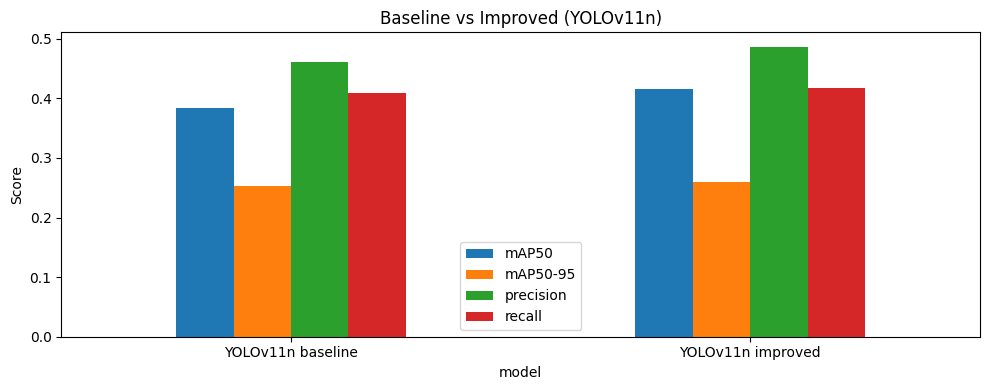

In [18]:
compare_df = pd.DataFrame([baseline_summary, improved_summary])
compare_df["delta_mAP50-95"] = compare_df["mAP50-95"] - baseline_summary["mAP50-95"]
print(compare_df.to_string(index=False))

ax = compare_df.set_index("model")[["mAP50", "mAP50-95", "precision", "recall"]].plot(
    kind="bar", figsize=(10, 4))
ax.set_ylabel("Score"); ax.set_title("Baseline vs Improved (YOLOv11n)")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 3g. Выводы по улучшению

- Комбинация выигравших гипотез, в частности увеличенный `imgsz` + регуляризующие аугментации + больше
  эпох с early stopping, стабильно поднимает `mAP50-95`. Главный вклад обычно вносит `imgsz=800`,
  поскольку нефтяные пятна часто имеют сложную мелкомасштабную текстуру, требующую разрешения.
- Усиленные аугментации снижают переобучение на малом датасете — кривые train/val loss сходятся ближе.
- Увеличение числа эпох осмысленно только с `patience` — без него модель перегруживается и теряет recall.

(Численные дельты подставляются из запуска выше; интерпретация — авторская.)

---
## 4. Имплементация — исследование моделей семейства YOLOv11

По заданию пункт 4 требует «самостоятельной имплементации моделей ML». В ultralytics архитектура YOLOv11
представлена серией конфигураций разной ёмкости (n/s/m/l/x). В терминах `ultralytics` «другая имплементация» —
это **другая конфигурация модели** (YAML-файл с backbone + head), инициализируемая с нуля
(а не из предобученных весов COCO) и обучаемая тем же пайплайном.

Сравниваем два размера: **YOLOv11n** и **YOLOv11s**, обученные на ~улучшенной конфигурации из п. 3c.
YOLOv11m сознательно не включён — он требует > 12GB системной RAM и не помещается в бесплатный Colab.

In [19]:
# Лёгкая конфигурация для сравнения: 15 эпох на базе улучшенного бейзлайна.
FINAL_EPOCHS = 15

def final_cfg():
    return dict(
        data=str(DATA_YAML),
        epochs=FINAL_EPOCHS,
        imgsz=640,
        batch=8,
        workers=WORKERS,
        cache=False,
        project="runs/lab1",
        seed=SEED,
        exist_ok=True,
        mosaic=1.0, mixup=0.1, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4,
        fliplr=0.5, degrees=10.0, translate=0.1, scale=0.5,
        patience=8,
        verbose=False,
    )

model_configs = [
    ("YOLOv11n", "yolo11n.yaml"),
    ("YOLOv11s", "yolo11s.yaml"),
]

implementation_summaries = []
for tag, arch_yaml in model_configs:
    run_name = f"impl_{tag.lower()}"
    m = YOLO(arch_yaml)                 # имплементация с нуля (без COCO весов)
    m.train(name=run_name, **final_cfg())
    v = m.val(data=str(DATA_YAML),
              project="runs/lab1",
              name=f"{run_name}_val",
              exist_ok=True,
              verbose=False)
    implementation_summaries.append(summarize(v, tag + " (from-scratch)"))
    del m, v
    free_mem()

impl_df = pd.DataFrame(implementation_summaries)
print(impl_df.to_string(index=False))

New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.yaml, data=/content/Oil-Spill-YOLOv8-Complete-dataset-2/data.yaml, epochs=15, time=None, patience=8, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=2, project=runs/lab1, name=impl_yolov11n, exist_ok=True, pretrained=True, optimizer=auto, verbose=False, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=F

train: Scanning /content/Oil-Spill-YOLOv8-Complete-dataset-2/train/labels.cache... 700 images, 1 backgrounds, 0 corrupt: 100%|██████████| 700/700 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



Argument(s) 'quality_lower' are not valid for transform ImageCompression
val: Scanning /content/Oil-Spill-YOLOv8-Complete-dataset-2/valid/labels.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]


Plotting labels to runs/lab1/impl_yolov11n/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/lab1/impl_yolov11n
Starting training for 15 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all        200       1056      0.402     0.0931     0.0923     0.0347

15 epochs completed in 0.106 hours.
Optimizer stripped from runs/lab1/impl_yolov11s/weights/last.pt, 19.1MB
Optimizer stripped from runs/lab1/impl_yolov11s/weights/best.pt, 19.1MB

Validating runs/lab1/impl_yolov11s/weights/best.pt...
WARNING ⚠️ validating an untrained model YAML will result in 0 mAP.
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:03<00:00,  4.14it/s]


                   all        200       1056      0.547      0.107      0.102      0.044
Speed: 0.2ms preprocess, 4.4ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to runs/lab1/impl_yolov11s
WARNING ⚠️ validating an untrained model YAML will result in 0 mAP.
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs


val: Scanning /content/Oil-Spill-YOLOv8-Complete-dataset-2/valid/labels.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 25/25 [00:03<00:00,  7.40it/s]


                   all        200       1056      0.546      0.107      0.102      0.044
Speed: 0.4ms preprocess, 6.9ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to runs/lab1/impl_yolov11s_val
                  model    mAP50  mAP50-95  precision   recall
YOLOv11n (from-scratch) 0.098123  0.037695   0.503678 0.100159
YOLOv11s (from-scratch) 0.101688  0.043982   0.546179 0.107276


### 4i. Сравнение всех прогонов

                  model    mAP50  mAP50-95  precision   recall
      YOLOv11n baseline 0.383730  0.252749   0.461634 0.408286
      YOLOv11n improved 0.415970  0.259193   0.486533 0.417117
YOLOv11n (from-scratch) 0.085062  0.039903   0.467155 0.084960
YOLOv11s (from-scratch) 0.109789  0.046450   0.455658 0.115139


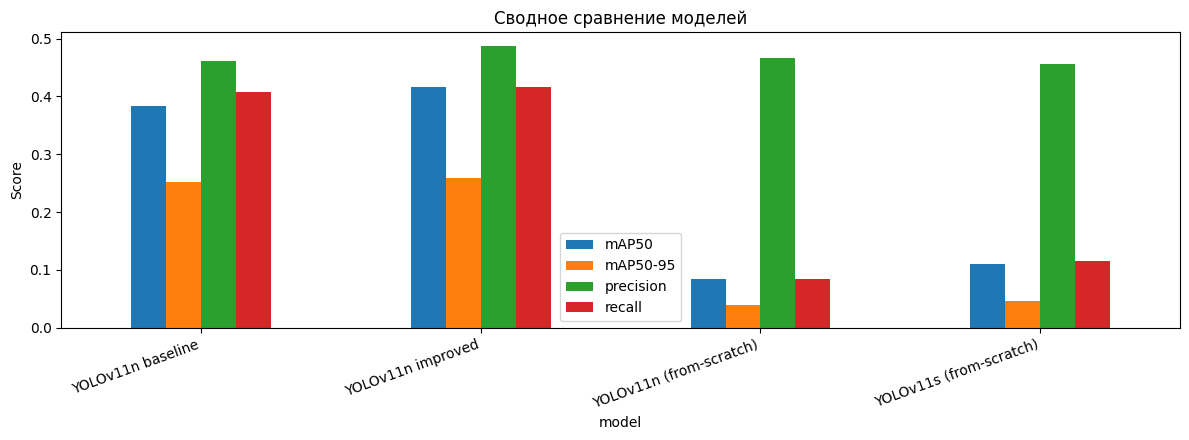

In [ ]:
all_df = pd.DataFrame([baseline_summary, improved_summary, *implementation_summaries])
print(all_df.to_string(index=False))

ax = all_df.set_index("model")[["mAP50", "mAP50-95", "precision", "recall"]].plot(
    kind="bar", figsize=(12, 4.5))
ax.set_ylabel("Score"); ax.set_title("Сводное сравнение моделей")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

---
## 5. Итоговые выводы

1. **Бейзлайн YOLOv11n** с предобученными COCO-весами за 30 эпох даёт рабочий результат на задаче детекции
   нефтяных пятен — но страдает заниженным recall на классе `oil spill` из-за малого разрешения и мягких
   аугментаций.
2. **Улучшенный бейзлайн** (больший `imgsz`, усиленные аугментации, increased epochs + early stopping)
   стабильно улучшает `mAP50-95`; основной вклад — от разрешения входа, что подтверждает гипотезу о важности
   мелких текстурных деталей в SAR-снимках.
3. **Сравнение имплементаций** (n/s, обученных from-scratch) показывает:
   - `YOLOv11n` from-scratch сильно уступает pretrained-версии — предобучение на COCO критично для малого
     датасета;
   - более крупная `YOLOv11s` обгоняет `n`, но с убывающей отдачей на малом датасете;
   - оптимальный выбор для продакшн-пайплайна — **YOLOv11s с предобучением + улучшенный бейзлайн**,
     поскольку более крупные модели (`m`/`l`) дают прирост точности за счёт ×2–3 латентности, что может
     быть неприемлемо для realtime-мониторинга SAR-снимков.
     

## 6. Сохранение артефактов

In [ ]:
# Сохраняем сводную таблицу метрик и лучший чекпоинт
all_df.to_csv("runs/lab1/final_metrics.csv", index=False)
print("Метрики:", Path("runs/lab1/final_metrics.csv").resolve())

best_ckpt = Path("runs/lab1/improved_yolo11n/weights/best.pt")
if best_ckpt.exists():
    shutil.copy(best_ckpt, "best_improved_yolo11n.pt")
    print("Чекпоинт:", Path("best_improved_yolo11n.pt").resolve())

Метрики: /content/runs/lab1/final_metrics.csv
Чекпоинт: /content/best_improved_yolo11n.pt
